<a href="https://colab.research.google.com/github/aminnademi/Clinical-Synthetic-Data-Audit/blob/main/pima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install sdv

# Import Required Libraries

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wasserstein_distance

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, brier_score_loss

import sdv
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, TVAESynthesizer

In [3]:
OUT_DIR = Path("pima_benchmark_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed()

# Load Dataset & EDA

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, header=None, names=columns)

TARGET = "Outcome"
FEATURES = df.columns.drop(TARGET)

In [5]:
df.shape

(768, 9)

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
Zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in Zeros:
    df[col] = df[col].replace(0, np.nan)

df[Zeros].isnull().sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


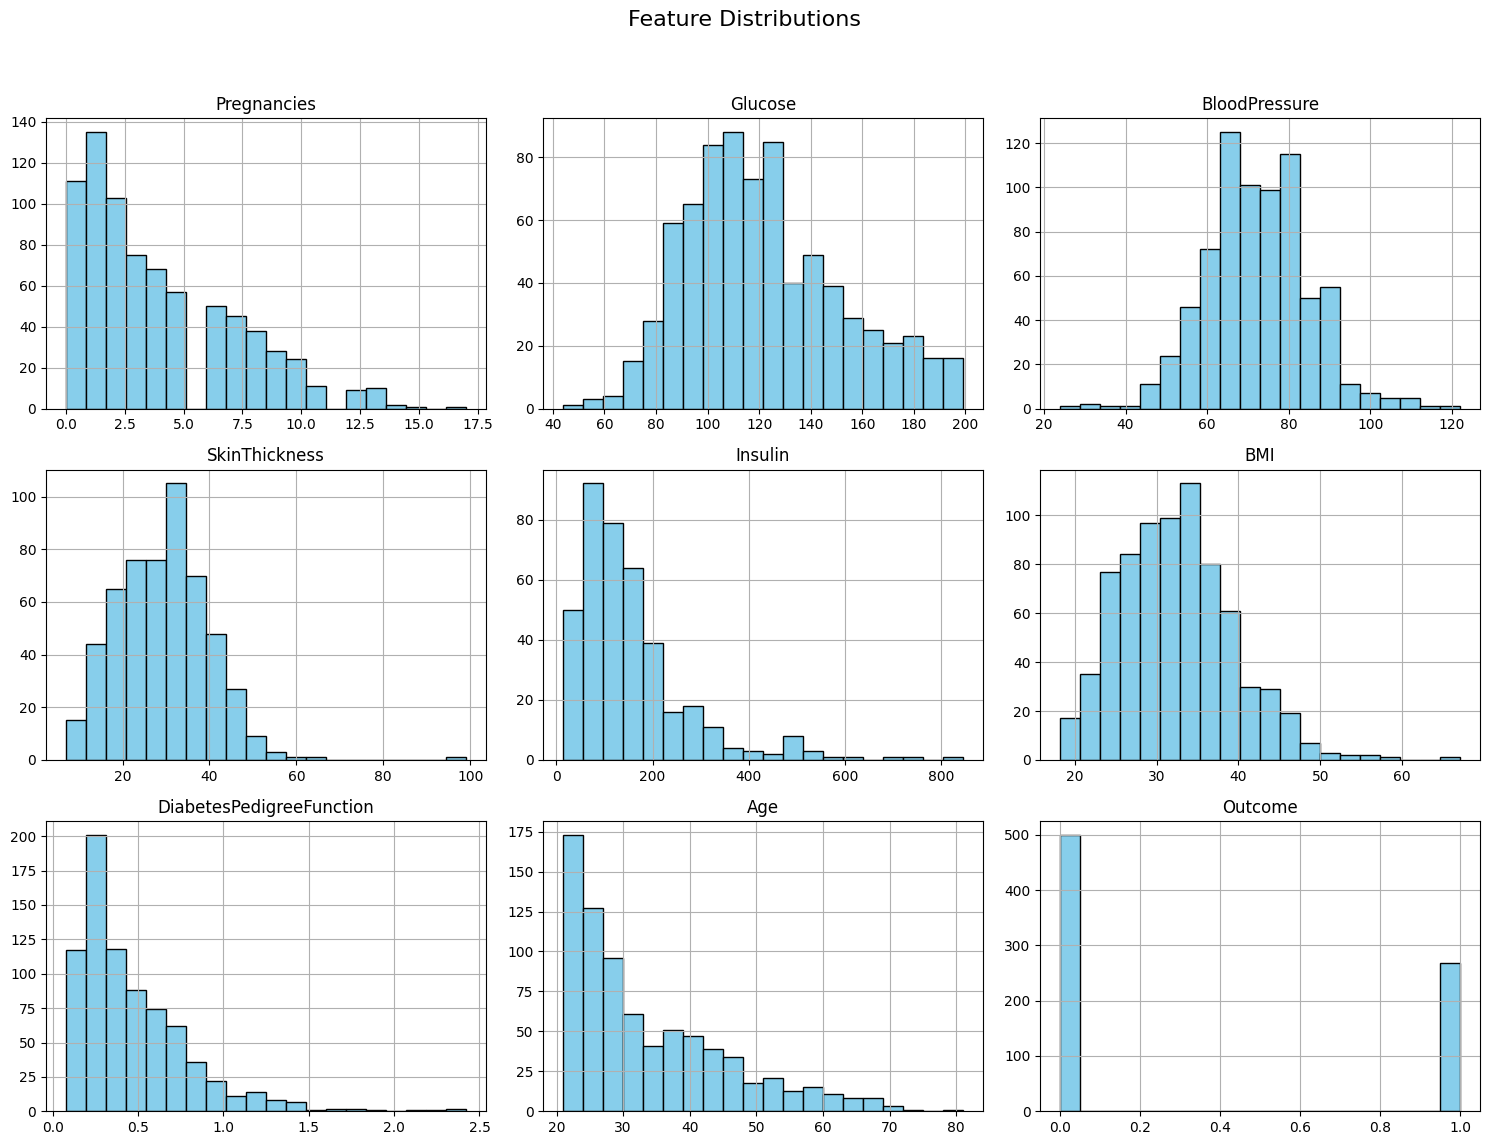

In [10]:
df.hist(figsize=(15, 12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

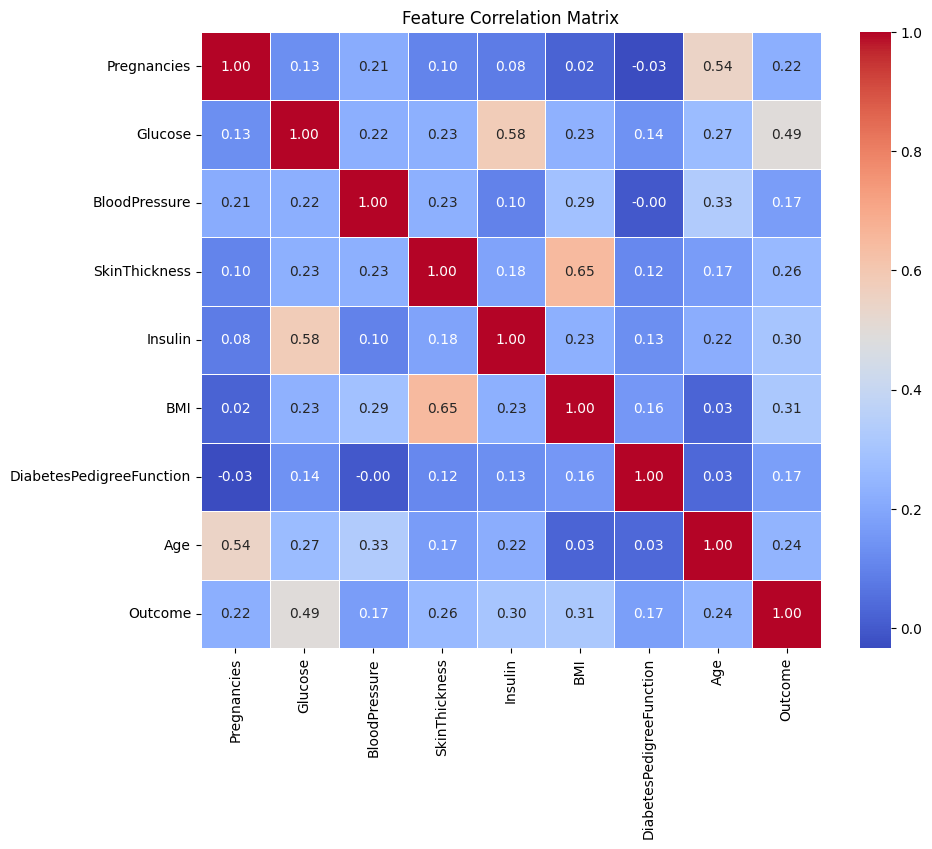

In [11]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

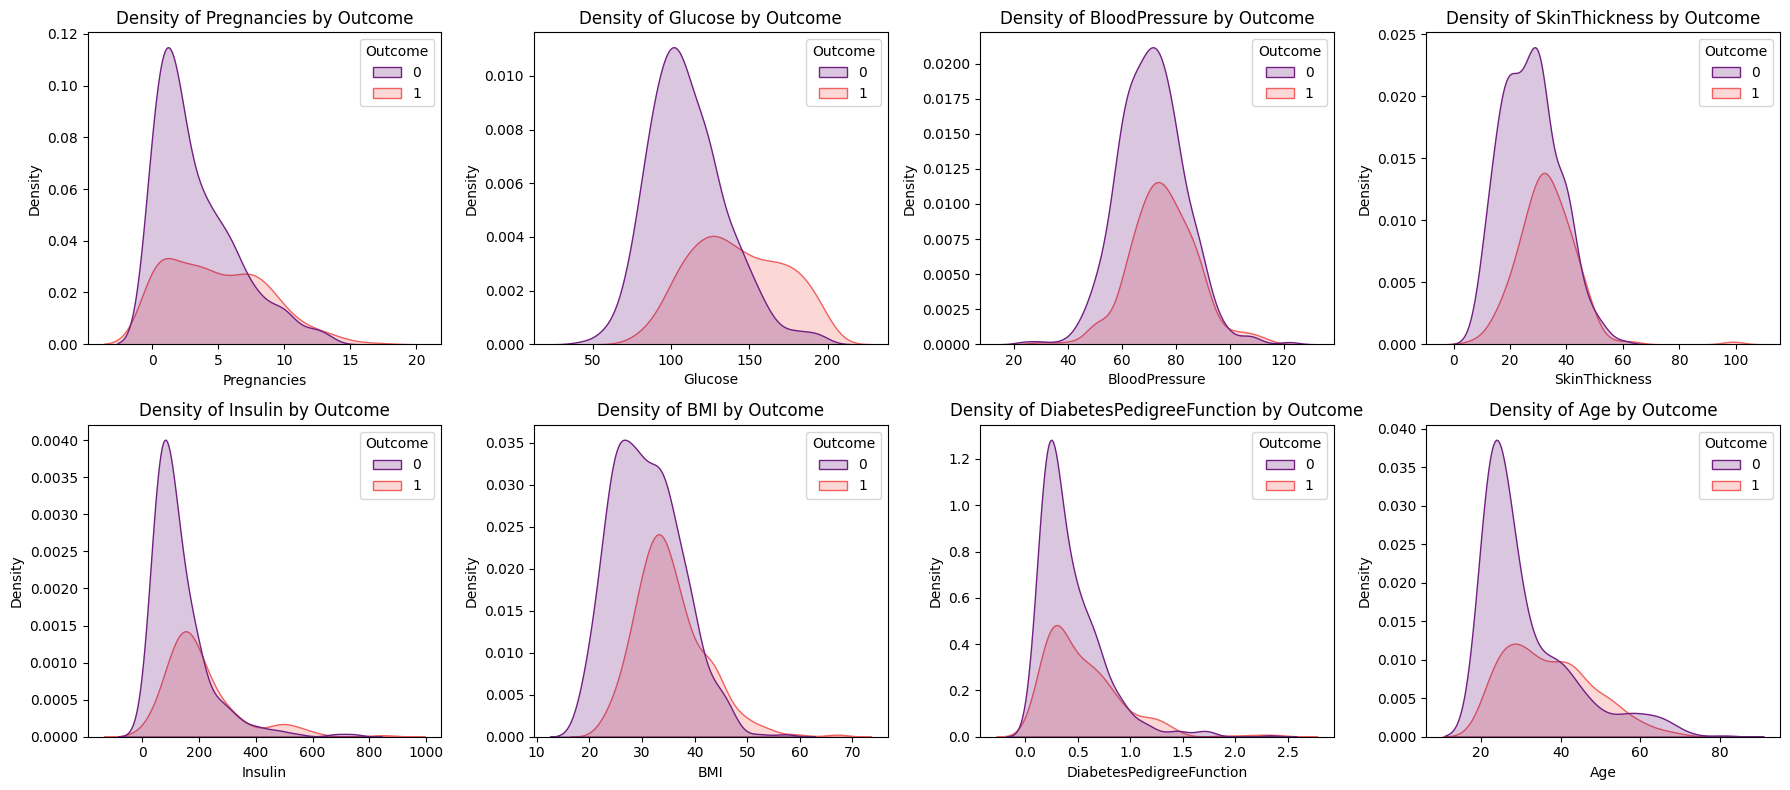

In [12]:
# Plotting KDE for key features to see class separation
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    sns.kdeplot(data=df, x=col, hue=TARGET, fill=True, ax=axes[i], palette='magma')
    axes[i].set_title(f'Density of {col} by Outcome')

plt.tight_layout()
plt.show()

# Pre-Processing

In [13]:
X = df[FEATURES].copy()
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

In [14]:
imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=FEATURES,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=FEATURES,
    index=X_test.index
)

train_model_df = X_train.copy()
train_model_df[TARGET] = y_train

# For Later
test_model_df = X_test.copy()
test_model_df[TARGET] = y_test

### SDV for Metadata

In [15]:
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(train_model_df)

metadata.update_column(
    column_name=TARGET,
    sdtype="categorical"
)

display(pd.DataFrame(
    metadata.to_dict()["columns"]
).T)

,sdtype
Pregnancies,numerical
Glucose,numerical
BloodPressure,numerical
SkinThickness,numerical
Insulin,numerical
BMI,numerical
DiabetesPedigreeFunction,numerical
Age,numerical
Outcome,categorical


# Training Process

In [17]:
CTGAN_EPOCHS = 300
TVAE_EPOCHS = 300

ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=CTGAN_EPOCHS,
    enforce_min_max_values=False,
    enforce_rounding=True,
    verbose=False,
)

tvae = TVAESynthesizer(
    metadata=metadata,
    epochs=TVAE_EPOCHS,
    enforce_min_max_values=False,
    enforce_rounding=True,
    verbose=False,
)

print("[+] Training CTGAN...")
set_seed()
ctgan.fit(train_model_df)

print("[+] Training TVAE...")
set_seed()
tvae.fit(train_model_df)

print("[+] Finished.")

/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


[+] Training CTGAN...
[+] Training TVAE...
[+] Finished.


### Generate 1000 Records

In [18]:
N = 1000
synthetic = {}
tabddpm_path = OUT_DIR / "tabddpm_raw.csv"

print("[+] Sampling CTGAN...")
set_seed()

synthetic["CTGAN"] = ctgan.sample(num_rows=N)

print("[+] Sampling TVAE...")
set_seed()

synthetic["TVAE"] = tvae.sample(num_rows=N)

for name in synthetic:
    data = synthetic[name].copy()

    data[TARGET] = (
        pd.to_numeric(
            data[TARGET],
            errors="coerce"
        )
        .round()
        .clip(0, 1)
        .astype(int)
    )

    synthetic[name] = data

    data.to_csv(
        OUT_DIR / f"{name.lower()}_raw.csv",
        index=False
    )

# Add TabDDPM Samples Manually
if tabddpm_path.exists():
    df_tabddpm = pd.read_csv(tabddpm_path)
    synthetic["TabDDPM"] = df_tabddpm
    print("[+] Sampling TabDDPM...")
else:
    print(f"[!] Not Found")

print({
    name: data.shape
    for name, data in synthetic.items()
})

[+] Sampling CTGAN...
[+] Sampling TVAE...
[+] Sampling TabDDPM...
{'CTGAN': (1000, 9), 'TVAE': (1000, 9), 'TabDDPM': (1000, 9)}


In [19]:
synthetic["CTGAN"].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.279000,129.585300,54.569000,32.088600,191.438500,28.368900,0.367738,33.736000,0.478000
std,3.697138,34.778286,13.085063,10.639326,98.940997,7.788078,0.342550,13.350451,0.499766
min,-4.000000,51.500000,23.600000,2.400000,9.400000,12.729594,-0.310000,10.000000,0.000000
25%,1.000000,105.300000,43.975000,26.000000,124.825000,22.892080,0.149750,24.000000,0.000000
50%,2.000000,128.550000,54.000000,32.300000,169.750000,27.846477,0.295000,29.000000,0.000000
75%,5.250000,151.625000,63.800000,38.300000,252.000000,33.284573,0.462000,41.000000,1.000000
max,17.000000,240.200000,109.700000,62.000000,940.700000,54.841947,2.619000,89.000000,1.000000


In [22]:
synthetic["TVAE"].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.624000,112.407500,66.664900,28.985500,131.260800,30.341222,0.312653,29.752000,0.181000
std,3.719739,26.451556,9.443922,8.810947,51.474858,5.966091,0.180346,9.957894,0.385211
min,-2.000000,56.500000,38.200000,5.000000,5.200000,16.671097,-0.023000,17.000000,0.000000
25%,1.000000,95.800000,60.275000,22.700000,91.525000,26.116810,0.198000,24.000000,0.000000
50%,2.000000,107.000000,66.300000,28.500000,135.000000,29.385224,0.268000,26.000000,0.000000
75%,7.000000,122.650000,73.200000,35.000000,170.025000,33.429818,0.357250,34.000000,0.000000
max,17.000000,212.000000,92.800000,54.000000,282.100000,51.669141,1.084000,82.000000,1.000000


In [23]:
synthetic["TabDDPM"].describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.326000,126.831512,73.141816,31.181890,202.883799,36.627744,0.913800,31.809000,0.354000
std,3.980398,44.288667,26.914253,15.799219,219.571981,15.141856,0.844857,13.958487,0.478448
min,0.000000,57.000000,24.000000,7.000000,16.000000,18.200001,0.084000,21.000000,0.000000
25%,0.000000,96.988458,62.257608,20.750075,71.076758,27.038696,0.263448,21.000000,0.000000
50%,2.000000,119.234844,72.518005,29.499543,133.456366,32.739190,0.525013,26.000000,0.000000
75%,5.000000,160.546782,82.800808,38.558935,194.950067,40.149740,1.729930,37.000000,1.000000
max,17.000000,198.000000,122.000000,60.000000,744.000000,67.099998,2.329000,81.000000,1.000000


# Clinical Rules

In [24]:
RULES = {
    "age_range":
        lambda r: 1 <= r["Age"] <= 120,

    "pregnancies_range":
        lambda r: 0 <= r["Pregnancies"] <= 20,

    "glucose_range":
        lambda r: 40 <= r["Glucose"] <= 400,

    "blood_pressure_range":
        lambda r: 30 <= r["BloodPressure"] <= 250,

    "skin_thickness_range":
        lambda r: 1 <= r["SkinThickness"] <= 100,

    "insulin_range":
        lambda r: 0 <= r["Insulin"] <= 1000,

    "bmi_range":
        lambda r: 10 <= r["BMI"] <= 80,

    "pedigree_range":
        lambda r: 0 <= r["DiabetesPedigreeFunction"] <= 5,

    "outcome_binary":
        lambda r: r[TARGET] in (0, 1),
}

In [25]:
def audit_rules(data):

    audited = data.copy()

    violation_columns = []

    for rule_name, rule_fn in RULES.items():

        col = f"violation__{rule_name}"

        audited[col] = ~audited.apply(rule_fn, axis=1)

        violation_columns.append(col)

    audited["violation_count"] = audited[violation_columns].sum(axis=1)

    audited["valid"] = audited["violation_count"] == 0

    return audited, violation_columns

In [26]:
audit_results = {}
curated = {}

for model_name, data in synthetic.items():

    audited, violation_columns = audit_rules(data)

    audit_results[model_name] = audited

    curated[model_name] = data.loc[audited["valid"], columns].reset_index(drop=True)

### Clinical Audit Table

In [27]:
audit_rows = []

for model_name, data in synthetic.items():

    audited = audit_results[model_name]

    violations = (~audited["valid"]).sum()

    audit_rows.append({
        "Generative Model": model_name,
        "Total Generated": len(data),
        "Violations": int(violations),
        "Violation Rate (%)":
            100 * violations / len(data),
        "Valid Retained":
            int(audited["valid"].sum()),
        "Valid Retained Yield (%)":
            100 * audited["valid"].mean(),
    })

audit_table = pd.DataFrame(audit_rows)

display(audit_table)

audit_table.to_csv(
    OUT_DIR / "clinical_rule_audit.csv",
    index=False
)

,Generative Model,Total Generated,Violations,Violation Rate (%),Valid Retained,Valid Retained Yield (%)
0,CTGAN,1000,148,14.8,852,85.2
1,TVAE,1000,21,2.1,979,97.9
2,TabDDPM,1000,119,11.9,881,88.1


# Statistical fidelity

In [28]:
def mean_wasserstein(real_data,synthetic_data, columns=FEATURES):

    distances = []

    for col in columns:

        real_values = real_data[col].astype(float).dropna().values

        synthetic_values = synthetic_data[col].astype(float).dropna().values

        distance = wasserstein_distance(real_values,synthetic_values)

        distances.append(distance)

    return float(np.mean(distances))

# Correlation preservation

In [29]:
def correlation_frobenius_distance(real_data, synthetic_data, columns=FEATURES):

    real_corr = real_data[columns].astype(float).corr().fillna(0).values

    synthetic_corr = synthetic_data[columns].astype(float).corr().fillna(0).values

    return float(np.linalg.norm(real_corr - synthetic_corr, ord="fro"))

### Fidelity table

In [30]:
fidelity_rows = []

for model_name, raw_data in synthetic.items():
    curated_data = curated[model_name]

    fidelity_rows.append({
        "Model": model_name,
        "Wasserstein Dist (Raw)": mean_wasserstein(train_model_df, raw_data),
        "Wasserstein Dist (Curated)": mean_wasserstein(train_model_df, curated_data),
        "Frobenius Corr Norm (Raw)": correlation_frobenius_distance(train_model_df, raw_data),
        "Frobenius Corr Norm (Curated)": correlation_frobenius_distance(train_model_df, curated_data),
    })

fidelity_table = pd.DataFrame(fidelity_rows)
display(fidelity_table)
fidelity_table.to_csv(OUT_DIR / "statistical_fidelity.csv", index=False)

,Model,Wasserstein Dist (Raw),Wasserstein Dist (Curated),Frobenius Corr Norm (Raw),Frobenius Corr Norm (Curated)
0,CTGAN,10.578168,10.069356,2.047443,2.059040
1,TVAE,5.147419,5.116768,0.640683,0.645189
2,TabDDPM,13.794588,13.519867,2.099220,3.015364


### ECE

In [31]:
def expected_calibration_error(y_true, probabilities, n_bins=10):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bins[i]
        upper = bins[i + 1]

        if i == n_bins - 1:
            mask = (probabilities >= lower) & (probabilities <= upper)
        else:
            mask = (probabilities >= lower) & (probabilities < upper)

        if mask.sum() == 0:
            continue

        predicted_probability = probabilities[mask].mean()
        accuracy = ((probabilities[mask] >= 0.5) == y_true[mask]).mean()
        ece += mask.mean() * abs(accuracy - predicted_probability)

    return float(ece)

# Downstream models

In [33]:
def make_classifier(name):
    if name == "RandomForest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced", n_jobs=-1))
        ])

    if name == "GradientBoosting":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42))
        ])

    if name == "LogisticRegression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=42))
        ])

    raise ValueError(f"Unknown classifier: {name}")

# TSTR function

In [34]:
CLASSIFIERS = ["RandomForest", "GradientBoosting", "LogisticRegression"]


def evaluate_downstream(training_data, test_data, classifier_name, condition, generator):
    X_train = training_data[FEATURES].copy()
    y_train = training_data[TARGET].astype(int).copy()

    X_test = test_data[FEATURES].copy()
    y_test = test_data[TARGET].astype(int).copy()

    # PIMA zero handling
    for col in Zeros:
        X_train[col] = X_train[col].replace(0, np.nan)
        X_test[col] = X_test[col].replace(0, np.nan)

    model = make_classifier(classifier_name)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    return {
        "Condition": condition,
        "Model": generator,
        "Classifier": classifier_name,
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "F1-Score": f1_score(y_test, predictions),
        "Brier Score": brier_score_loss(y_test, probabilities),
        "ECE": expected_calibration_error(y_test, probabilities),
    }

In [35]:
results = []

# Calculate Baseline (Real Data -> Real Data)
for classifier in CLASSIFIERS:
    result = evaluate_downstream(
        training_data=train_model_df,
        test_data=test_model_df,
        classifier_name=classifier,
        condition="Real Data (TRTR) Baseline",
        generator="Baseline"
    )
    results.append(result)

# Raw TSTR + Curated TSTR

In [36]:
for generator, raw_data in synthetic.items():

    curated_data = curated[generator]

    for classifier in CLASSIFIERS:

        # RAW
        raw_result = evaluate_downstream(
            training_data=raw_data,
            test_data=test_model_df,
            classifier_name=classifier,
            condition="Raw Synthetic (TSTR)",
            generator=generator
        )

        results.append(raw_result)

        # CURATED
        curated_result = evaluate_downstream(
            training_data=curated_data,
            test_data=test_model_df,
            classifier_name=classifier,
            condition="Curated Synthetic (TSTR)",
            generator=generator
        )

        results.append(curated_result)

# Final TSTR table

In [37]:
tstr_table = pd.DataFrame(results)

display(tstr_table.sort_values(["Model", "Condition", "Classifier"]))

tstr_table.to_csv(OUT_DIR / "tstr_results.csv",index=False)

,Condition,Model,Classifier,ROC-AUC,F1-Score,Brier Score,ECE
1,Real Data (TRTR) Baseline,Baseline,GradientBoosting,0.825679,0.562092,0.175492,0.489584
2,Real Data (TRTR) Baseline,Baseline,LogisticRegression,0.839177,0.571429,0.161361,0.468261
0,Real Data (TRTR) Baseline,Baseline,RandomForest,0.832922,0.586667,0.159406,0.423481
6,Curated Synthetic (TSTR),CTGAN,GradientBoosting,0.494568,0.478088,0.330343,0.331719
8,Curated Synthetic (TSTR),CTGAN,LogisticRegression,0.727737,0.571429,0.234222,0.268595
4,Curated Synthetic (TSTR),CTGAN,RandomForest,0.517860,0.500000,0.303473,0.293636
5,Raw Synthetic (TSTR),CTGAN,GradientBoosting,0.500494,0.500000,0.320255,0.326978
7,Raw Synthetic (TSTR),CTGAN,LogisticRegression,0.733416,0.600985,0.226408,0.279132
3,Raw Synthetic (TSTR),CTGAN,RandomForest,0.523457,0.475000,0.292002,0.287567
12,Curated Synthetic (TSTR),TVAE,GradientBoosting,0.802305,0.649007,0.187006,0.534522
